#Detecção Automática do Uso de Capacete por Motociclistas Utilizando Redes YOLO e Visão Computacional

### Instalação e importações

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os

###Descompactar dataset

In [ ]:
!unzip /content/dataset.zip -d /content/dataset/

Archive:  /content/dataset.zip
   creating: /content/dataset/dataset/
  inflating: /content/dataset/dataset/data.yaml  
   creating: /content/dataset/dataset/images/
   creating: /content/dataset/dataset/images/test/
  inflating: /content/dataset/dataset/images/test/a.jpeg  
  inflating: /content/dataset/dataset/images/test/aa.jpeg  
  inflating: /content/dataset/dataset/images/test/aaa.jpeg  
  inflating: /content/dataset/dataset/images/test/aab.jpeg  
  inflating: /content/dataset/dataset/images/test/aac.jpeg  
  inflating: /content/dataset/dataset/images/test/aad.jpeg  
  inflating: /content/dataset/dataset/images/test/aae.jpeg  
  inflating: /content/dataset/dataset/images/test/aaf.jpeg  
  inflating: /content/dataset/dataset/images/test/aag.jpeg  
  inflating: /content/dataset/dataset/images/test/aah.jpeg  
  inflating: /content/dataset/dataset/images/test/aai.jpeg  
  inflating: /content/dataset/dataset/images/test/aaj.jpeg  
  inflating: /content/dataset/dataset/images/test/ab.j

# Treinamento YOLOv8n

In [ ]:
# INSTALAÇÃO
from ultralytics import YOLO
import gc, torch, os
import pandas as pd

# CARREGAR O MODELO YOLOv8n
model = YOLO("yolov8n.pt")

# TREINAMENTO
history = model.train(
    data="/content/dataset/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="helmet_yolov8n",
    pretrained=True
)

# Avaliação do modelo (v8n)

In [ ]:
from ultralytics import YOLO
import numpy as np
import time
import cv2
import os

# Carregar modelo treinado
model = YOLO("/content/best8n.pt")

# Avaliação no conjunto de validação
metrics = model.val()

precision = metrics.results_dict["metrics/precision(B)"]
recall    = metrics.results_dict["metrics/recall(B)"]
map50     = metrics.results_dict["metrics/mAP50(B)"]
map5095   = metrics.results_dict["metrics/mAP50-95(B)"]

f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("===== MÉTRICAS yolo8n =====")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-score:    {f1:.4f}")
print(f"mAP@50:      {map50:.4f}")
print(f"mAP@50-95:   {map5095:.4f}")

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 404.9±140.0 MB/s, size: 16.5 KB)
val: Scanning /content/dataset/dataset/labels/val... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65 793.5it/s 0.1s
val: New cache created: /content/dataset/dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.5s/it 17.7s
                   all         65        271      0.713      0.757      0.766      0.397
    driver_with_helmet         44         54      0.747       0.82      0.854      0.418
 driver_without_helmet         53         63      0.836      0.873      0.867      0.465
 passenger_with_helmet         52         59      0.735      0.847      0.758      0.438
passenger_without_helmet         13         14      0.432      0.429      0.

# Avaliação do modelo (v9t)

In [ ]:
from ultralytics import YOLO
import numpy as np
import time
import cv2
import os

# Carregar modelo treinado
model = YOLO("/content/best9t.pt")

# Avaliação no conjunto de validação
metrics = model.val()

precision = metrics.results_dict["metrics/precision(B)"]
recall    = metrics.results_dict["metrics/recall(B)"]
map50     = metrics.results_dict["metrics/mAP50(B)"]
map5095   = metrics.results_dict["metrics/mAP50-95(B)"]

f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("===== MÉTRICAS yolov9t =====")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-score:    {f1:.4f}")
print(f"mAP@50:      {map50:.4f}")
print(f"mAP@50-95:   {map5095:.4f}")


Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv9t summary (fused): 197 layers, 1,972,149 parameters, 0 gradients, 7.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 230.9±73.0 MB/s, size: 15.6 KB)
val: Scanning /content/dataset/dataset/labels/val.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65 52.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.5s/it 22.5s
                   all         65        271      0.738      0.769      0.794      0.421
    driver_with_helmet         44         54      0.807      0.774      0.855      0.441
 driver_without_helmet         53         63       0.82      0.796      0.883        0.5
 passenger_with_helmet         52         59      0.771      0.858       0.78      0.473
passenger_without_helmet         13         14       0.52      0.697      0.608      0.389
                  bike         23         2

# Avaliação do modelo (v5n)

In [ ]:
# clonar repositório
!git clone https://github.com/ultralytics/yolov5.git


Cloning into 'yolov5'...
remote: Enumerating objects: 17757, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 17757 (delta 73), reused 39 (delta 39), pack-reused 17639 (from 4)
Receiving objects: 100% (17757/17757), 17.15 MiB | 14.79 MiB/s, done.
Resolving deltas: 100% (12055/12055), done.


In [ ]:
# entrar na pasta yolov5
%cd /content/yolov5

/content/yolov5


In [ ]:
!ls

benchmarks.py	 data	     LICENSE	     README.zh-CN.md   tutorial.ipynb
CITATION.cff	 detect.py   models	     requirements.txt  utils
classify	 export.py   pyproject.toml  segment	       val.py
CONTRIBUTING.md  hubconf.py  README.md	     train.py


In [ ]:
# instalar dependências
!pip install -r requirements.txt

In [ ]:
!cp -r /content/dataset/dataset/images /content/yolov5/
!cp -r /content/dataset/dataset/labels /content/yolov5/

In [ ]:
# avaliar modelo v5n
!python val.py \
    --weights /content/best5n.pt \
    --data data/data.yaml \
    --img 640 \
    --conf 0.25

val: data=data/data.yaml, weights=['/content/best5n.pt'], batch_size=32, imgsz=640, conf_thres=0.25, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.25 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-450-g781b9d57 Python-3.12.12 torch-2.9.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 1768636 parameters, 0 gradients, 4.2 GFLOPs
val: Scanning /content/yolov5/labels/val... 65 images, 0 backgrounds, 0 corrupt: 100% 65/65 [00:00<00:00, 1084.07it/s]
val: New cache created: /content/yolov5/labels/val.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 3/3 [00:15<00:00,  5.15s/it]
                   all         65        271      0.616      0.617      0.636      0.336
    driver_with_helmet         65         54  

In [ ]:
# Valores obtidos na validação (YOLOv5n)
precision = 0.616
recall = 0.617
map50 = 0.636
map5095 = 0.336

# Cálculo do F1-score
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("===== MÉTRICAS YOLOv5n =====")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-score:    {f1:.4f}")
print(f"mAP@50:      {map50:.4f}")
print(f"mAP@50-95:   {map5095:.4f}")

===== MÉTRICAS YOLOv5n =====
Precision:   0.6160
Recall:      0.6170
F1-score:    0.6165
mAP@50:      0.6360
mAP@50-95:   0.3360


# Criar tabela de resultados

In [ ]:
import pandas as pd

data = {
    "Modelo": ["YOLOv5n", "YOLOv8n", "YOLOv9t"],
    "Precision": [0.6160, 0.7131, 0.7377],
    "Recall": [0.6170, 0.7571, 0.7691],
    "F1-score": [0.6165, 0.7345, 0.7530],
    "mAP@50": [0.6360, 0.7660, 0.7942],
    "mAP@50-95": [0.3360, 0.3966, 0.4212]
}

df = pd.DataFrame(data)
df

,Modelo,Precision,Recall,F1-score,mAP@50,mAP@50-95
0,YOLOv5n,0.6160,0.6170,0.6165,0.6360,0.3360
1,YOLOv8n,0.7131,0.7571,0.7345,0.7660,0.3966
2,YOLOv9t,0.7377,0.7691,0.7530,0.7942,0.4212


# Precision dos modelos

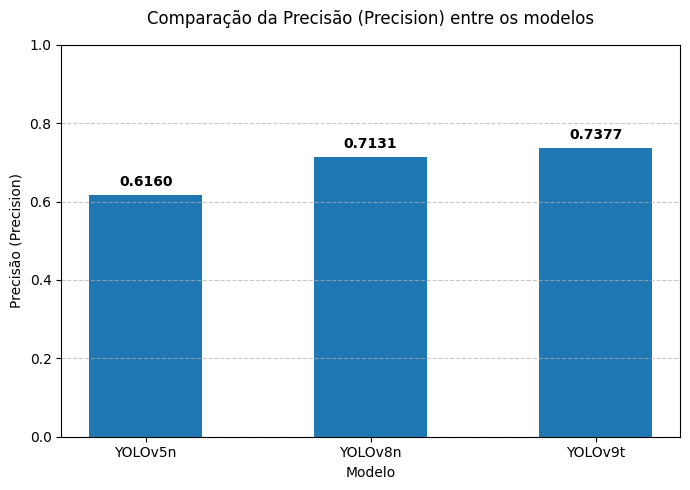

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Plot das barras para a métrica de Precisão
bars = plt.bar(df["Modelo"], df["Precision"], color="#1f77b4", width=0.5)

# Adiciona o valor exato no topo de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.015,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.title(
    "Comparação da Precisão (Precision) entre os modelos", fontsize=12, pad=15
)
plt.ylabel("Precisão (Precision)", fontsize=10)
plt.xlabel("Modelo", fontsize=10)

# Escala de 0 a 1 e linhas de grade horizontais
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# F1-score dos modelos

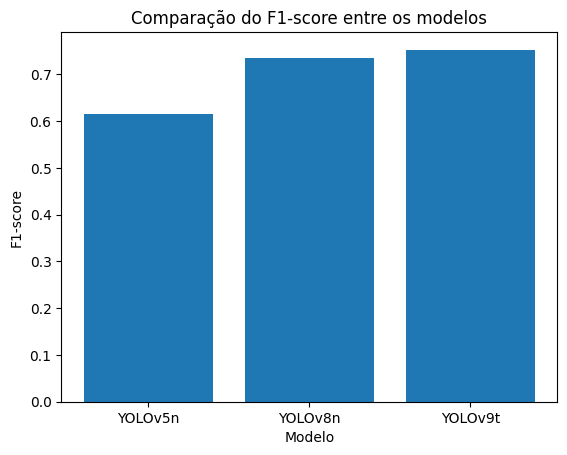

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Modelo"], df["F1-score"])
plt.title("Comparação do F1-score entre os modelos")
plt.ylabel("F1-score")
plt.xlabel("Modelo")
plt.show()

# mAP@50

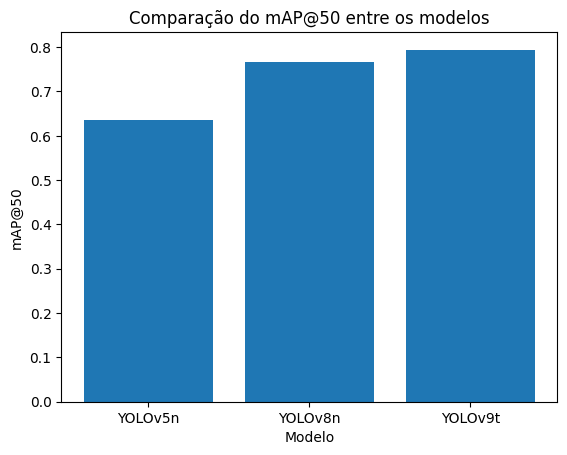

In [ ]:
plt.figure()
plt.bar(df["Modelo"], df["mAP@50"])
plt.title("Comparação do mAP@50 entre os modelos")
plt.ylabel("mAP@50")
plt.xlabel("Modelo")
plt.show()

# mAP50-95

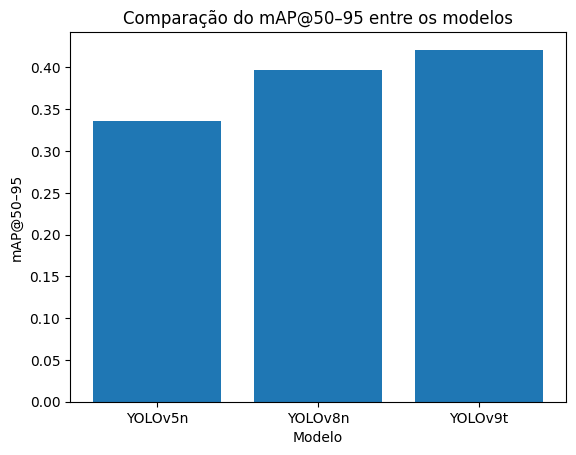

In [ ]:
plt.figure()
plt.bar(df["Modelo"], df["mAP@50-95"])
plt.title("Comparação do mAP@50–95 entre os modelos")
plt.ylabel("mAP@50–95")
plt.xlabel("Modelo")
plt.show()

# Gráfico Único Comparativo (todas as métricas)
Esse gráfico compara Precision, Recall, F1-score, mAP@50 e mAP@50–95 dos três modelos em um único gráfico.

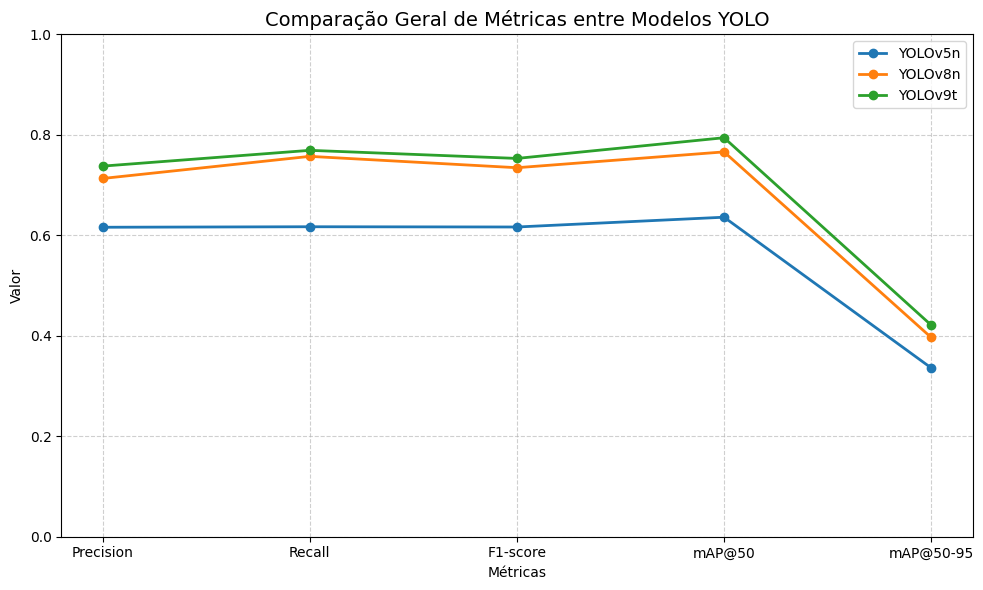

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados dos modelos
data = {
    "Modelo": ["YOLOv5n", "YOLOv8n", "YOLOv9t"],
    "Precision": [0.6160, 0.7131, 0.7377],
    "Recall": [0.6170, 0.7571, 0.7691],
    "F1-score": [0.6165, 0.7345, 0.7530],
    "mAP@50": [0.6360, 0.7660, 0.7942],
    "mAP@50-95": [0.3360, 0.3966, 0.4212]
}

df = pd.DataFrame(data)

metrics = ["Precision", "Recall", "F1-score", "mAP@50", "mAP@50-95"]

plt.figure(figsize=(10, 6))

for i, model in enumerate(df["Modelo"]):
    plt.plot(
        metrics,
        df.loc[i, metrics],
        marker='o',
        linewidth=2,
        label=model
    )

plt.title("Comparação Geral de Métricas entre Modelos YOLO", fontsize=14)
plt.xlabel("Métricas")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Testando os modelos em vídeos/imagens de autoria própria.

In [ ]:
# ============================================================
# INSTALAÇÃO DO YOLOv5
# ============================================================

!git clone https://github.com/ultralytics/yolov5.git /content/yolov5

%cd /content/yolov5

!pip install -r requirements.txt -q

%cd /content

Cloning into '/content/yolov5'...
remote: Enumerating objects: 18756, done.
remote: Counting objects: 100% (331/331), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 18756 (delta 271), reused 140 (delta 139), pack-reused 18425 (from 4)
Receiving objects: 100% (18756/18756), 17.75 MiB | 23.57 MiB/s, done.
Resolving deltas: 100% (12764/12764), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.4 MB/s eta 0:00:00
/content


In [ ]:
# ============================================================
# INSTALAÇÃO DO ULTRALYTICS
# ============================================================

!pip install -U ultralytics -q

In [ ]:
# ============================================================
# CONFIGURAÇÕES
# ============================================================

# Caminho da imagem que será utilizada no teste
caminho_imagem = "/content/foto_scapacete2.jpg"

# Caminho dos modelos
caminho_modelo_yolov5n = "/content/best5n.pt"
caminho_modelo_yolov8n = "/content/best8n.pt"
caminho_modelo_yolov9 = "/content/best9t.pt"

# Confiança mínima para considerar uma detecção
confianca_minima = 0.75

# Diretório para salvar os resultados
diretorio_resultados = "/content/resultados_modelos"

In [ ]:
# ============================================================
# IMPORTAÇÕES
# ============================================================

import os
import time
import torch
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO

os.makedirs(diretorio_resultados, exist_ok=True)

print("Bibliotecas carregadas com sucesso!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Bibliotecas carregadas com sucesso!


In [ ]:
# ============================================================
# CARREGAR YOLOv5n
# ============================================================

print("Carregando YOLOv5n...")

modelo_yolov5n = torch.hub.load(
    "/content/yolov5",
    "custom",
    path=caminho_modelo_yolov5n,
    source="local"
)

# Confiança mínima
modelo_yolov5n.conf = confianca_minima

# Se disponível, utiliza GPU
if torch.cuda.is_available():
    modelo_yolov5n.to("cuda")

print("YOLOv5n carregado com sucesso!")
print("Classes:", modelo_yolov5n.names)

Carregando YOLOv5n...
YOLOv5 🚀 v7.0-552-g35b48237 Python-3.13.15 torch-2.11.0+cpu CPU

Fusing layers... 
Model summary: 68 layers, 1,768,636 parameters, 0 gradients, 4.2 GFLOPs
Adding AutoShape... 
YOLOv5n carregado com sucesso!
Classes: {0: 'driver_with_helmet', 1: 'driver_without_helmet', 2: 'passenger_with_helmet', 3: 'passenger_without_helmet', 4: 'bike', 5: 'driver_general', 6: 'passenger_general'}


In [ ]:
# ============================================================
# CARREGAR YOLOv8n
# ============================================================

print("Carregando YOLOv8n...")

modelo_yolov8n = YOLO(caminho_modelo_yolov8n)

print("YOLOv8n carregado com sucesso!")
print("Classes:", modelo_yolov8n.names)


# ============================================================
# CARREGAR YOLOv9
# ============================================================

print("\nCarregando YOLOv9...")

modelo_yolov9 = YOLO(caminho_modelo_yolov9)

print("YOLOv9 carregado com sucesso!")
print("Classes:", modelo_yolov9.names)

Carregando YOLOv8n...
YOLOv8n carregado com sucesso!
Classes: {0: 'driver_with_helmet', 1: 'driver_without_helmet', 2: 'passenger_with_helmet', 3: 'passenger_without_helmet', 4: 'bike', 5: 'driver_general', 6: 'passenger_general'}

Carregando YOLOv9...
YOLOv9 carregado com sucesso!
Classes: {0: 'driver_with_helmet', 1: 'driver_without_helmet', 2: 'passenger_with_helmet', 3: 'passenger_without_helmet', 4: 'bike', 5: 'driver_general', 6: 'passenger_general'}


In [ ]:
# ============================================================
# TESTE YOLOv5n
# ============================================================

print("Testando YOLOv5n...")

inicio_yolov5n = time.time()

resultado_yolov5n = modelo_yolov5n(caminho_imagem)

fim_yolov5n = time.time()

tempo_yolov5n = fim_yolov5n - inicio_yolov5n

print("Teste YOLOv5n concluído!")
print(f"Tempo de inferência: {tempo_yolov5n:.4f} segundos")

Testando YOLOv5n...
Teste YOLOv5n concluído!
Tempo de inferência: 0.2820 segundos


In [ ]:
# ============================================================
# TESTE YOLOv8n
# ============================================================

print("Testando YOLOv8n...")

inicio_yolov8n = time.time()

resultado_yolov8n = modelo_yolov8n(
    caminho_imagem,
    conf=confianca_minima,
    verbose=False
)

fim_yolov8n = time.time()

tempo_yolov8n = fim_yolov8n - inicio_yolov8n

print("Teste YOLOv8n concluído!")
print(f"Tempo de inferência: {tempo_yolov8n:.4f} segundos")

Testando YOLOv8n...
Teste YOLOv8n concluído!
Tempo de inferência: 0.3650 segundos


In [ ]:
# ============================================================
# TESTE YOLOv9
# ============================================================

print("Testando YOLOv9...")

inicio_yolov9 = time.time()

resultado_yolov9 = modelo_yolov9(
    caminho_imagem,
    conf=confianca_minima,
    verbose=False
)

fim_yolov9 = time.time()

tempo_yolov9 = fim_yolov9 - inicio_yolov9

print("Teste YOLOv9 concluído!")
print(f"Tempo de inferência: {tempo_yolov9:.4f} segundos")

Testando YOLOv9...
Teste YOLOv9 concluído!
Tempo de inferência: 0.4855 segundos


In [ ]:
# ============================================================
# PREPARAR RESULTADOS
# ============================================================

imagem_yolov5n = resultado_yolov5n.render()[0]

imagem_yolov8n = resultado_yolov8n[0].plot()

imagem_yolov9 = resultado_yolov9[0].plot()

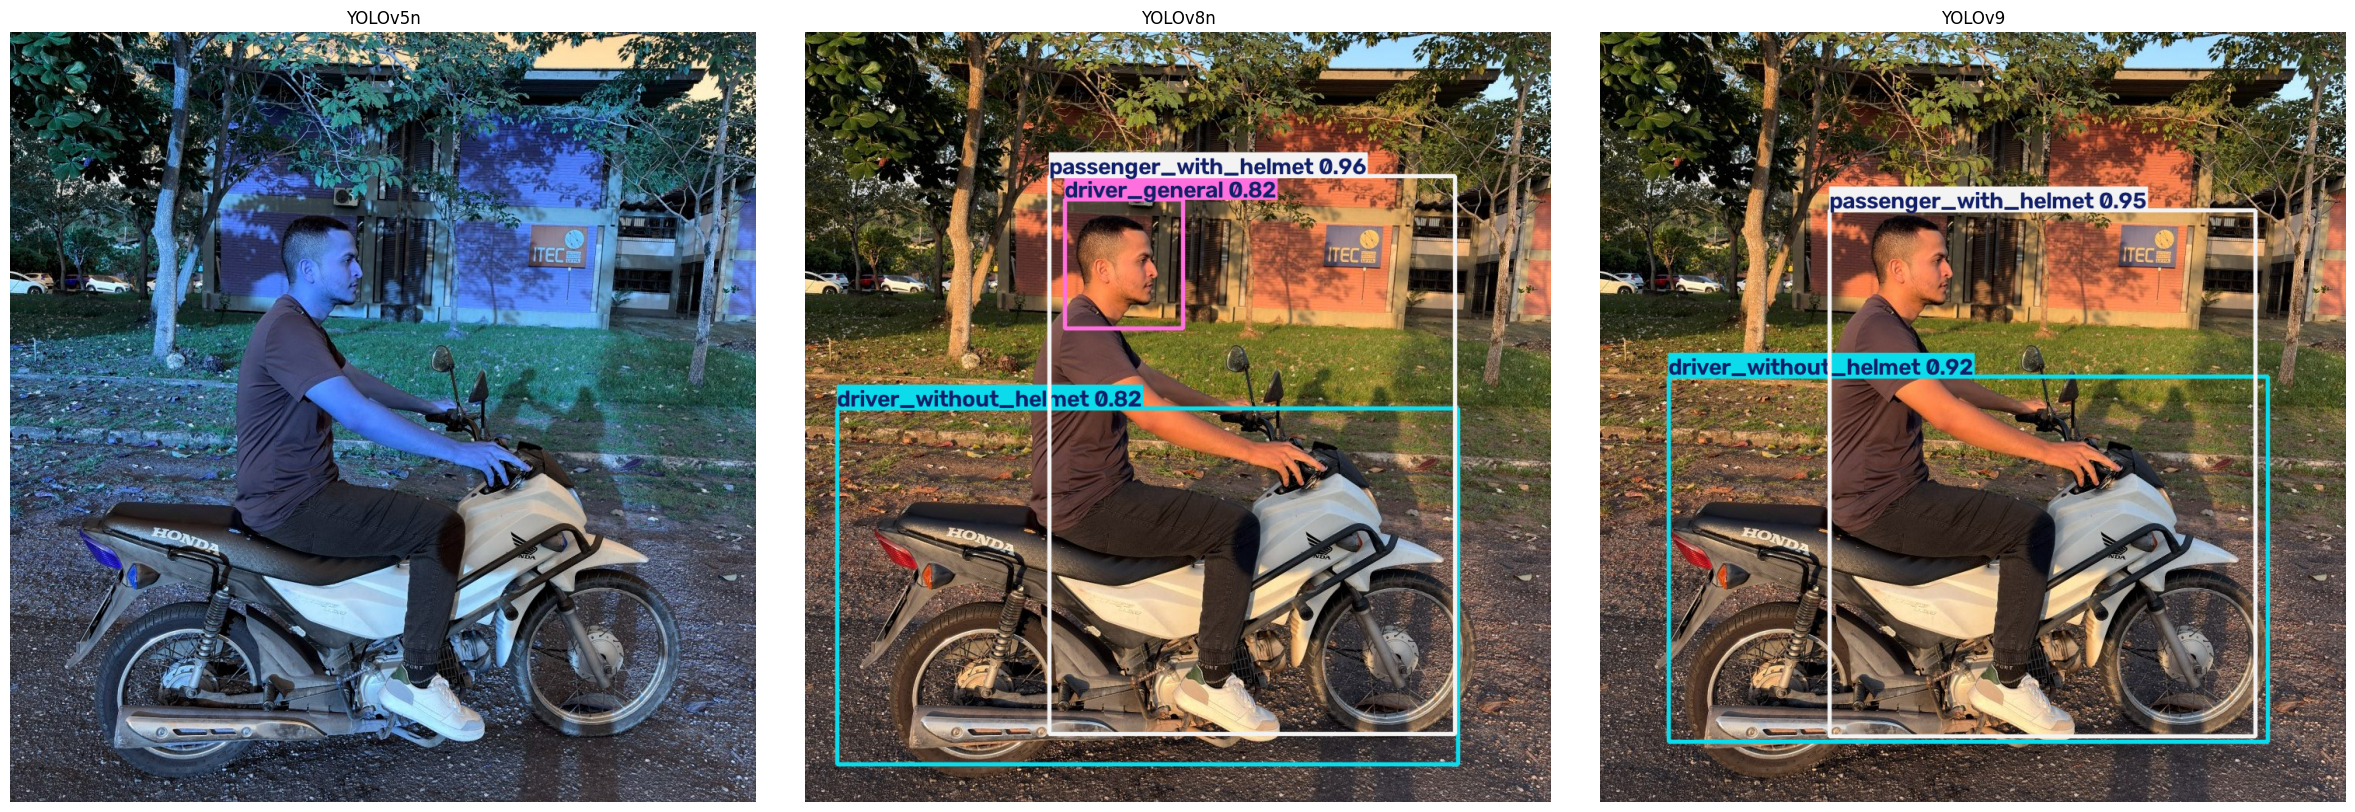

In [ ]:
# ============================================================
# COMPARAÇÃO VISUAL
# ============================================================

figura, eixos = plt.subplots(1, 3, figsize=(24, 8))

# YOLOv5n
eixos[0].imshow(
    cv2.cvtColor(imagem_yolov5n, cv2.COLOR_BGR2RGB)
)

eixos[0].set_title("YOLOv5n")
eixos[0].axis("off")


# YOLOv8n
eixos[1].imshow(
    cv2.cvtColor(imagem_yolov8n, cv2.COLOR_BGR2RGB)
)

eixos[1].set_title("YOLOv8n")
eixos[1].axis("off")


# YOLOv9
eixos[2].imshow(
    cv2.cvtColor(imagem_yolov9, cv2.COLOR_BGR2RGB)
)

eixos[2].set_title("YOLOv9")
eixos[2].axis("off")


plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FUNÇÃO PARA MOSTRAR DETECÇÕES
# ============================================================

def mostrar_deteccoes_yolov5(resultado, nome_modelo):

    print("\n" + "=" * 60)
    print(nome_modelo)
    print("=" * 60)

    deteccoes = resultado.xyxy[0]

    if len(deteccoes) == 0:
        print("Nenhuma detecção encontrada.")
        return

    for deteccao in deteccoes:

        classe = int(deteccao[5])
        confianca = float(deteccao[4])

        nome_classe = resultado.names[classe]

        print(
            f"Classe: {nome_classe} | "
            f"Confiança: {confianca:.2%}"
        )


def mostrar_deteccoes_ultralytics(resultado, nome_modelo):

    print("\n" + "=" * 60)
    print(nome_modelo)
    print("=" * 60)

    caixas = resultado[0].boxes

    if len(caixas) == 0:
        print("Nenhuma detecção encontrada.")
        return

    for caixa in caixas:

        classe = int(caixa.cls[0])
        confianca = float(caixa.conf[0])

        nome_classe = resultado[0].names[classe]

        print(
            f"Classe: {nome_classe} | "
            f"Confiança: {confianca:.2%}"
        )

In [ ]:
# ============================================================
# EXIBIR DETECÇÕES
# ============================================================

mostrar_deteccoes_yolov5(
    resultado_yolov5n,
    "YOLOv5n"
)

mostrar_deteccoes_ultralytics(
    resultado_yolov8n,
    "YOLOv8n"
)

mostrar_deteccoes_ultralytics(
    resultado_yolov9,
    "YOLOv9"
)


YOLOv5n
Nenhuma detecção encontrada.

YOLOv8n
Classe: passenger_with_helmet | Confiança: 96.22%
Classe: driver_without_helmet | Confiança: 82.24%
Classe: driver_general | Confiança: 81.93%

YOLOv9
Classe: passenger_with_helmet | Confiança: 94.82%
Classe: driver_without_helmet | Confiança: 91.63%


In [ ]:
# ============================================================
# FPS APROXIMADO
# ============================================================

fps_yolov5n = 1 / tempo_yolov5n
fps_yolov8n = 1 / tempo_yolov8n
fps_yolov9 = 1 / tempo_yolov9

print("==========================================")
print("FPS APROXIMADO")
print("==========================================")

print(f"YOLOv5n: {fps_yolov5n:.2f} FPS")
print(f"YOLOv8n: {fps_yolov8n:.2f} FPS")
print(f"YOLOv9:  {fps_yolov9:.2f} FPS")

FPS APROXIMADO
YOLOv5n: 3.55 FPS
YOLOv8n: 2.74 FPS
YOLOv9:  2.06 FPS


In [ ]:
# ============================================================
# SALVAR RESULTADOS
# ============================================================

caminho_resultado_yolov5n = (
    f"{diretorio_resultados}/resultado_YOLOv5n.jpg"
)

caminho_resultado_yolov8n = (
    f"{diretorio_resultados}/resultado_YOLOv8n.jpg"
)

caminho_resultado_yolov9 = (
    f"{diretorio_resultados}/resultado_YOLOv9.jpg"
)


# YOLOv5n
cv2.imwrite(
    caminho_resultado_yolov5n,
    imagem_yolov5n
)


# YOLOv8n
cv2.imwrite(
    caminho_resultado_yolov8n,
    imagem_yolov8n
)


# YOLOv9
cv2.imwrite(
    caminho_resultado_yolov9,
    imagem_yolov9
)

print("Resultados salvos!")

Resultados salvos!


In [ ]:
# ============================================================
# QUANTIDADE DE DETECÇÕES
# ============================================================

quantidade_yolov5n = len(resultado_yolov5n.xyxy[0])
quantidade_yolov8n = len(resultado_yolov8n[0].boxes)
quantidade_yolov9 = len(resultado_yolov9[0].boxes)

print("==========================================")
print("QUANTIDADE DE DETECÇÕES")
print("==========================================")

print(f"YOLOv5n: {quantidade_yolov5n}")
print(f"YOLOv8n: {quantidade_yolov8n}")
print(f"YOLOv9:  {quantidade_yolov9}")

QUANTIDADE DE DETECÇÕES
YOLOv5n: 0
YOLOv8n: 3
YOLOv9:  2


In [ ]:
# ============================================================
# TEMPO DE INFERÊNCIA
# ============================================================

print("==========================================")
print("TEMPO DE INFERÊNCIA")
print("==========================================")

print(f"YOLOv5n: {tempo_yolov5n:.4f} segundos")
print(f"YOLOv8n: {tempo_yolov8n:.4f} segundos")
print(f"YOLOv9:  {tempo_yolov9:.4f} segundos")

TEMPO DE INFERÊNCIA
YOLOv5n: 0.2820 segundos
YOLOv8n: 0.3650 segundos
YOLOv9:  0.4855 segundos


In [ ]:
# ============================================================
# RESUMO
# ============================================================

print("\n")
print("=" * 70)
print("RESUMO DOS TESTES")
print("=" * 70)

print(
    f"{'Modelo':<12}"
    f"{'Detecções':<15}"
    f"{'Tempo (s)':<15}"
    f"{'FPS':<10}"
)

print("-" * 70)

print(
    f"{'YOLOv5n':<12}"
    f"{quantidade_yolov5n:<15}"
    f"{tempo_yolov5n:<15.4f}"
    f"{fps_yolov5n:<10.2f}"
)

print(
    f"{'YOLOv8n':<12}"
    f"{quantidade_yolov8n:<15}"
    f"{tempo_yolov8n:<15.4f}"
    f"{fps_yolov8n:<10.2f}"
)

print(
    f"{'YOLOv9':<12}"
    f"{quantidade_yolov9:<15}"
    f"{tempo_yolov9:<15.4f}"
    f"{fps_yolov9:<10.2f}"
)

print("=" * 70)



RESUMO DOS TESTES
Modelo      Detecções      Tempo (s)      FPS       
----------------------------------------------------------------------
YOLOv5n     0              0.2820         3.55      
YOLOv8n     3              0.3650         2.74      
YOLOv9      2              0.4855         2.06      
